# Inertial modes modified by magnetic forces

In [1]:
%load_ext autoreload
%autoreload 2

import os, h5py, pgpy_utils
import numpy as np
import sympy as sym
import matplotlib.pyplot as plt
import utils
from scipy import special as specfun
from scipy import interpolate
import inertial_modes as m_inert

---
## Boundary layer correction

In [2]:
import sympy as sym
from inertial_modes import s, z, r, phi, theta
alpha = sym.Symbol(r'\alpha')

In [3]:
map_cyl2sph = {s: r*sym.sin(theta), z: r*sym.cos(theta)}

def cross(vA, vB):
    prod_A_B = [
        vA[1]*vB[2] - vA[2]*vB[1],
        vA[2]*vB[0] - vA[0]*vB[2],
        vA[0]*vB[1] - vA[1]*vB[0],
    ]
    return prod_A_B

def dot(vA, vB):
    prod_A_B = vA[0]*vB[0] + vA[1]*vB[1] + vA[2]*vB[2]
    return prod_A_B

def conj(vA):
    v_conj = [sym.conjugate(v_comp) for v_comp in vA]
    return v_conj

def curl_sph_m(v, m_val):
    curl_v = [
        (sym.diff(sym.sin(theta)*v[2], theta) - sym.I*m_val*v[1])/(r*sym.sin(theta)),
        (sym.I*m_val*v[0]/sym.sin(theta) - sym.diff(r*v[2], r))/r,
        (sym.diff(r*v[1], r) - sym.diff(v[0], theta))/r
    ]
    return curl_v

def curl_cyl_m(v, m_val):
    curl_v = [
        sym.I*m_val/s*v[2] - sym.diff(v[1], z),
        sym.diff(v[0], z) - sym.diff(v[2], s),
        sym.diff(s*v[1], s)/s - sym.I*m_val/s*v[0]
    ]
    return curl_v

### Magnetic boundary layer solution

Base state

In [4]:
print(m_inert.eigenfreq_inviscid(0, 1, parity='a', n=18))

[1.00000000000000000]


In [19]:
B0r = sym.cos(theta)
N_geo = 1
m_val = 3
i_val = 0

sigma_0 = m_inert.eigenfreq_inviscid(N_geo, m_val, parity='s', n=18)[i_val]/2
# sigma_0 = 0.5
lambda_0 = 2*sym.I*sigma_0
u0_cyl = m_inert.eigenmode_poly_inviscid(N_geo, parity='s')
u0_cyl = [u_comp.subs({m_inert.m: m_val}) for u_comp in u0_cyl]
# u0_cyl = [sym.I*z, -z, -sym.I*s]
u0_sph = [u_comp.subs(map_cyl2sph) for u_comp in u0_cyl]
u0_sph = [
    u0_sph[0]*sym.sin(theta) + u0_sph[2]*sym.cos(theta), 
    u0_sph[0]*sym.cos(theta) - u0_sph[2]*sym.sin(theta),
    u0_sph[1]
]

parsub = {
    m_inert.elamb: lambda_0, 
    m_inert.sigma: sigma_0, 
    alpha: (1 + sym.I*sym.sign(sym.im(lambda_0)))*sym.sqrt(sym.Abs(sym.im(lambda_0))/2)}
display(lambda_0)

-0.253197264742180826*I

z-profiles

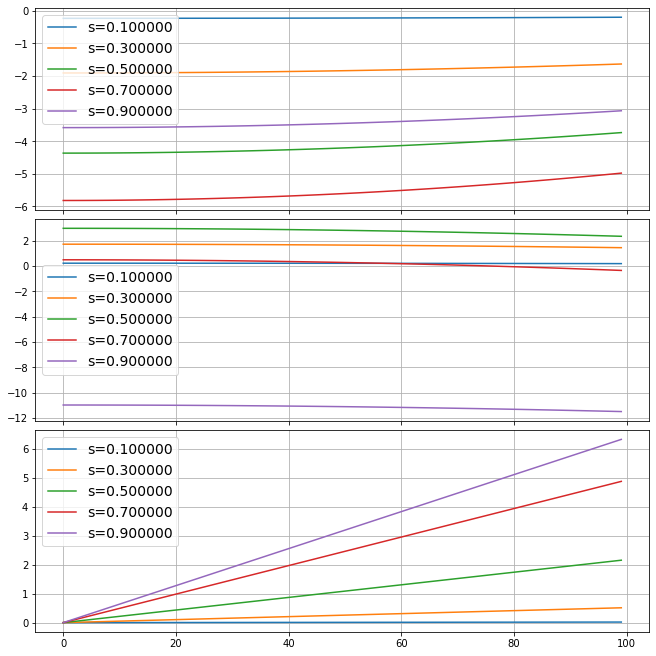

In [20]:
u0_f = [sym.lambdify([m_inert.s, m_inert.z, m_inert.sigma], comp, modules=['scipy', 'numpy'])
    for comp in u0_cyl]

s_locs = [0.1, 0.3, 0.5, 0.7, 0.9]
z_arr = np.linspace(0., 1., num=100)

def plot_profile(f, s_loc, z, sigma, ax, label=None):
    H = np.sqrt(1 - s_loc**2)
    f_vals = f(s_loc, H*z, sigma)
    ax.plot(np.real(f_vals) + np.imag(f_vals), label=label)

fig, axes = plt.subplots(nrows=3, figsize=(9, 9), layout='constrained', sharex=True)
for i_comp in range(3):
    ax = axes[i_comp]
    for i_s, s_tmp in enumerate(s_locs):
        plot_profile(u0_f[i_comp], s_tmp, z_arr, float(sigma_0), ax, label='s=%f' % s_tmp)
    ax.legend(fontsize=14)
    ax.grid(True, which='both')
    
plt.show()

In [23]:
u0_cyl[0]

-I*(-315*\sigma**2*s**2*z**2*(3*\sigma + 3)/(4*(1 - \sigma**2)) - 315*s**4*(5*\sigma + 3)/32 + 35*s**2*(3*\sigma + 3)/(4*(1 - \sigma**2)))

Background field

In [7]:
# B0 = [sym.S.Zero, 3*sym.sqrt(3)/2*s*(1 - s**2 - z**2), sym.S.Zero]
B0 = [sym.S.Zero, sym.S.Zero, sym.S.One]
B0_sph = [B_comp.subs(map_cyl2sph) for B_comp in B0]
B0_sph = [
    B0_sph[0]*sym.sin(theta) + B0_sph[2]*sym.cos(theta), 
    B0_sph[0]*sym.cos(theta) - B0_sph[2]*sym.sin(theta),
    B0_sph[1]
]

Interior solution

In [8]:
order = 0

b1_in_cyl = curl_cyl_m(cross(u0_cyl, B0), m_val=m_val)
for i_order in range(order):
    b1_in_cyl = -curl_cyl_m(curl_cyl_m(b1_in_cyl), m_val=m_val)
b1_in_cyl = [b_comp/(m_inert.elamb**(int(order) + 1)) for b_comp in b1_in_cyl]

b1_in_sph = [b_comp.subs(map_cyl2sph) for b_comp in b1_in_cyl]
b1_in_sph = [
    b1_in_sph[0]*sym.sin(theta) + b1_in_sph[2]*sym.cos(theta), 
    b1_in_sph[0]*sym.cos(theta) - b1_in_sph[2]*sym.sin(theta),
    b1_in_sph[1]
]

First-order boundary layer solution

In [9]:
N_SH = 30

u0_b = [u_comp.subs({r: 1}).trigsimp() for u_comp in u0_sph]
b1_in_b = [b_comp.subs({r: 1}).trigsimp() for b_comp in b1_in_sph]

f_b1r = sym.lambdify([theta,], b1_in_b[0].subs(parsub), modules=['numpy', 'scipy'])
f_b1t_b_int = sym.lambdify([theta,], b1_in_b[1].subs(parsub), modules=['numpy', 'scipy'])
f_b1p_b_int = sym.lambdify([theta,], b1_in_b[2].subs(parsub), modules=['numpy', 'scipy'])
f_b1t_b, f_b1p_b, cf = m_inert.rad2tan_B_single_m(f_b1r, N_SH, m_val)
print(cf)

f_b1t_bl = lambda t: f_b1t_b(t) - f_b1t_b_int(t)
f_b1p_bl = lambda t: f_b1p_b(t) - f_b1p_b_int(t)

[ 1.25600315e-14 -1.28375799e+00 -1.50542965e-15  4.93726829e-01
 -4.73753564e-17 -2.49031989e-01  2.56765573e-16  1.45295317e-01
 -1.78143024e-16  3.49655153e-17  5.67725892e-17 -3.33501022e-17
 -8.06428897e-18  1.00102214e-17  4.14258373e-18  1.77410636e-18
  1.98692286e-18 -2.01037698e-17 -2.70662921e-18  3.01623000e-17
  3.66609880e-18 -2.32536830e-17 -6.18837812e-18  1.50392228e-17
  4.97110507e-18 -6.40215932e-18 -1.57769643e-18  1.64637510e-19]


Second-order boundary layer solution

In [10]:
dr_r2_b1r_in_b = sym.diff(r**2*b1_in_sph[0], r).subs({r: 1})
f_dr_r2_b1r_in_b = sym.lambdify([theta,], dr_r2_b1r_in_b.subs(parsub), modules=['numpy', 'scipy'])

def f_b1hr_bl0(t):
    xi_t = np.cos(t)
    basis = np.stack([specfun.lpmn(m_val, N_SH, xi_tmp)[0][m_val, m_val:] for xi_tmp in xi_t], axis=0)
    n_arr = np.arange(m_val, N_SH + 1)
    return (-1/complex(parsub[alpha]))*(basis @ (cf*n_arr*(n_arr + 1)) + f_dr_r2_b1r_in_b(t))

f_b1ht_bl0, f_b1hp_bl0, cf_1h = m_inert.rad2tan_B_single_m(f_b1hr_bl0, N_SH, m_val)
print(cf_1h)

f_b1ht_bl1 = f_b1t_bl
f_b1hp_bl1 = f_b1p_bl

[ 5.57306062e-12+5.57306062e-12j  2.49534535e+02+2.49534535e+02j
 -3.87624155e-13-3.87624155e-13j -8.15742617e+01-8.15742617e+01j
 -2.72081215e-13-2.72081215e-13j  3.06573762e+01+3.06573762e+01j
  8.32712362e-14+8.32712362e-14j -9.88478349e+00-9.88478349e+00j
 -3.42333216e-15-3.42333216e-15j  3.75072614e-14+3.75072614e-14j
  1.33248032e-14+1.33248032e-14j -1.82405519e-14-1.82405519e-14j
 -8.44991851e-15-8.44991851e-15j -1.97011688e-14-1.97011688e-14j
 -4.17096554e-15-4.17096554e-15j  2.51264465e-14+2.51264465e-14j
  1.52613572e-15+1.52613572e-15j -2.80637863e-15-2.80637863e-15j
  1.57454198e-15+1.57454198e-15j -1.60787240e-14-1.60787240e-14j
  5.44358549e-16+5.44358549e-16j  1.26274763e-14+1.26274763e-14j
 -1.35401620e-15-1.35401620e-15j -1.13664210e-15-1.13664210e-15j
  5.44742406e-16+5.44742406e-16j -2.03169660e-15-2.03169660e-15j
 -1.69450363e-16-1.69450363e-16j  3.29615284e-16+3.29615284e-16j]


### Eigenvalue correction

Normalizer

In [11]:
u0_mod_sq = dot(conj(u0_sph), u0_sph)
f_u0_mod_sq = sym.lambdify([r, theta], u0_mod_sq.subs(parsub), modules=['numpy', 'scipy'])
# u0_l2 = float(m_inert.int_ball_axisym(u0_mod_sq))
u0_l2 = m_inert.quad_ball_axisym(f_u0_mod_sq)

Interior contribution

In [12]:
L_in_A = cross(curl_sph_m(b1_in_sph, m_val=m_val), B0_sph)
L_in_B = cross(curl_sph_m(B0_sph, m_val=0), b1_in_sph)
L_in_sph = [(L_in_A[i_comp] + L_in_B[i_comp]) for i_comp in range(3)]
# L_in_sph = [(L_in_A[i_comp] + L_in_B[i_comp]).simplify() for i_comp in range(3)]

f_uL_in = sym.lambdify([r, theta], dot(conj(u0_sph), L_in_sph).subs(parsub), modules=['numpy', 'scipy'])
inner_u_L_in = m_inert.quad_ball_axisym(f_uL_in)

First-order boundary layer contribution

In [13]:
f_u0t_b = sym.lambdify([theta,], u0_b[1].subs(parsub), modules=['numpy', 'scipy'])
f_u0p_b = sym.lambdify([theta,], u0_b[2].subs(parsub), modules=['numpy', 'scipy'])
f_B0r = sym.lambdify([theta,], B0_sph[0], modules=['numpy', 'scipy'])
f_surf = lambda t: f_B0r(t)*(
    + np.conj(f_u0t_b(t))*f_b1t_bl(t)
    + np.conj(f_u0p_b(t))*f_b1p_bl(t)
)
inner_u_L_bl = m_inert.quad_sph_surf_axisym(f_surf)

Second-order boundary layer contribution

In [14]:
psi_0 = [cross(u0_sph, curl_sph_m(B0_sph, m_val=0)), curl_sph_m(cross(u0_sph, B0_sph), m_val=m_val)]
psi_0 = [psi_0[0][i_comp] - psi_0[1][i_comp] for i_comp in range(3)]
f_psi_0t = sym.lambdify([theta,], psi_0[1].subs({r: 1, **parsub}), modules=['numpy', 'scipy'])
f_psi_0p = sym.lambdify([theta,], psi_0[2].subs({r: 1, **parsub}), modules=['numpy', 'scipy'])
f_surf_1 = lambda t: f_B0r(t)*(
    + np.conj(f_u0t_b(t))*f_b1ht_bl0(t)
    + np.conj(f_u0p_b(t))*f_b1hp_bl0(t)
)
f_surf_2 = lambda t: (
    + np.conj(f_psi_0t(t))*f_b1t_bl(t)
    + np.conj(f_psi_0p(t))*f_b1p_bl(t)
)/complex(parsub[alpha])
inner_u_L_bl2 = m_inert.quad_sph_surf_axisym(f_surf_1) + m_inert.quad_sph_surf_axisym(f_surf_2)

Final contributions

In [15]:
lambda_2_0 = (inner_u_L_in + inner_u_L_bl)/u0_l2
lambda_2_1 = inner_u_L_bl2/u0_l2
print(inner_u_L_in, inner_u_L_bl, lambda_2_0, lambda_2_1, sep='\n')

3.589138941606507e-08j
-199494.6062969565j
-12.624716578541037j
(-2073.6795067009866+2073.6795067009866j)


---
## Numerical solutions

In [16]:
import models
from operators.polynomials import SphericalHarmonicMode
from operators.worland_transform import WorlandTransform
from operators.associated_legendre_transform import AssociatedLegendreTransformSingleM
from fields import VectorFieldSingleM

nr, maxnl, m_val = 93, 93, 3

# bg_modes = [SphericalHarmonicMode("pol", 1, 0, "Sqrt[pi/3] r")]
# model = models.MagnetoCoriolis_Spin_bAlfven(nr, maxnl, m_val, inviscid=True,
#     induction_eq_params={'galerkin': False, 'ideal': False, 'boundary_condition': True})

model = models.InertialModes(nr, maxnl, m_val, inviscid=True, bc_type=None)

In [17]:
Le_list = np.logspace(-6, -2, num=9)
Em_list = np.logspace(-8, -2, num=13)
Le_mesh, Em_mesh = np.meshgrid(Le_list, Em_list, indexing='ij')

seeds = np.array([
    # -0.0476406312805127j, 
    # +0.5129638919619019j, 
    # -1.022179200470604j,
    +1.00000001j
])

### Inviscid inertial modes

In [41]:
Nev = 5
eigenvals = list()
eigenvecs = list()

A, B = model.setup_operator(setup_eigen=True)
for i_target, target in enumerate(seeds):
    w, v = utils.single_eig(A, B, target=target, nev=Nev)
    eigenvals.append(w)
    eigenvecs.append(v.T)

eigenvals = np.array(eigenvals)
eigenvecs = np.array(eigenvecs)

In [32]:
with h5py.File('./runs/Inertial_inviscid/emodes_m1.h5', 'w') as fh5:
    n_gp = len(fh5.keys())
    for i_eig in range(seeds.size):
        gp = fh5.create_group(f'eig_{n_gp}')
        gp.create_dataset('eigenvals', data=eigenvals[i_eig, :])
        gp.create_dataset('eigenvecs', data=eigenvecs[i_eig, ...])
        n_gp += 1

#### Inertial mode visualisation

Prepare spectral transforms

In [42]:
nr, maxnl, m_val = 91, 91, 1

rg = specfun.roots_chebyt(401)[0]
rg = rg[rg.size//2:]
tg = np.linspace(0, np.pi, 201)
rr, tt = np.meshgrid(rg, tg)

worland_transform = WorlandTransform(nr, maxnl, m_val, r_grid=rg)
legendre_transform = AssociatedLegendreTransformSingleM(maxnl, m_val, tg)

In [43]:
with h5py.File('./runs/Inertial_inviscid/emodes_m1.h5', 'r') as fh5:
    for i_gp in range(len(fh5.keys())):
        print(i_gp, fh5[f'eig_{i_gp}']['eigenvals'][()], sep='\n')

0
[-1.65853784e-20+1.j          5.35246057e-18+1.00013892j
  5.09245457e-18+1.00014379j  1.55870667e-17+1.00014902j
 -4.93429681e-19+1.00015464j]


Select a mode

In [44]:
i_eig = 0
i_ev = 0

with h5py.File('./runs/Inertial_inviscid/emodes_m1.h5', 'r') as fh5:
    gp = fh5[f'eig_{i_eig}']
    eigval = gp['eigenvals'][i_ev]
    eigvec = gp['eigenvecs'][i_ev, :]

usp = VectorFieldSingleM(nr, maxnl, m_val, eigvec)
usp.normalise(np.sqrt(usp.energy))
u_sph = usp.physical_field(worland_transform, legendre_transform).data

Visualise

In [45]:
# lon_deg = 30
# lon_rad = np.radians(lon_deg)
max_id = np.unravel_index(np.argmax(np.abs(u_sph['phi'])), u_sph['phi'].shape)
lon_rad = -np.angle(u_sph['phi'][max_id])/m_val + np.pi/15
lon_deg = np.degrees(lon_rad)

X1, X2 = rr*np.sin(tt), rr*np.cos(tt)

fields = {
    'v_r': u_sph['r']*np.exp(1j*m_val*lon_rad), 
    'v_t': u_sph['theta']*np.exp(1j*m_val*lon_rad),
    'v_p': u_sph['phi']*np.exp(1j*m_val*lon_rad), 
    'v_s': (u_sph['r']*np.sin(tt) + u_sph['theta']*np.cos(tt))*np.exp(1j*m_val*lon_rad), 
    'v_z': (u_sph['r']*np.cos(tt) - u_sph['theta']*np.sin(tt))*np.exp(1j*m_val*lon_rad),
}

C:\Users\gentle\AppData\Local\Temp\ipykernel_9892\2081593415.py:47: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  cm = ax.pcolormesh(X1, X2, field_plot/norm, vmin=-1e-7, vmax=+1e-7, cmap='coolwarm')


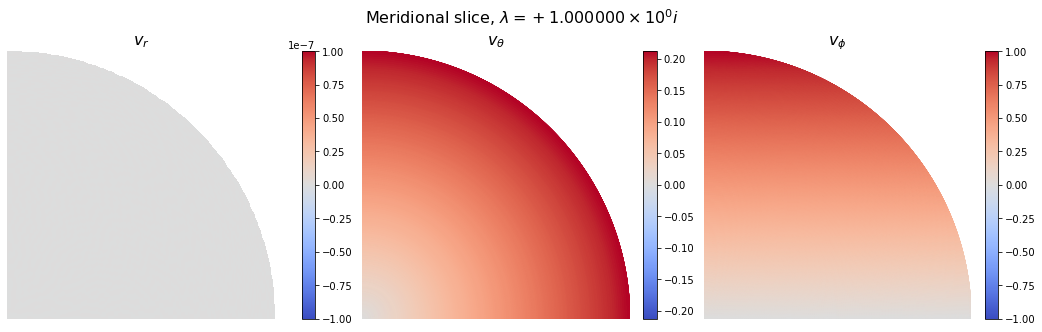

In [46]:
coordinates = 'sph'
override = False
force_lines = False
force_symmetric_cmap = True
domain = 'hemi'
save_name = f"./runs/Inertial_inviscid/v_m1_md_spinover_{coordinates}_{domain}"
save_name = None

if coordinates == 'sph':
    plot_fields = [['v_r', 'v_t', 'v_p'],]
    plot_fnames = [[r"$v_r$", r"$v_\theta$", r"$v_\phi$"],]
else:
    plot_fields = [['v_s', 'v_z', 'v_p'],]
    plot_fnames = [[r"$v_s$", r"$v_z$", r"$v_\phi$"],]

norm = np.abs(np.real(fields['v_p'])).max()
if force_lines:
    x_grid = np.linspace(0., 1., num=100)
    y_grid = np.linspace(-1., 1., num=200)
    XX, YY = np.meshgrid(x_grid, y_grid)
    vs_grid = interpolate.griddata((X1.flatten(), X2.flatten()), np.real(fields['v_s']).flatten(), (XX, YY))
    vz_grid = interpolate.griddata((X1.flatten(), X2.flatten()), np.real(fields['v_z']).flatten(), (XX, YY))

nrows, ncols = len(plot_fields), len(plot_fields[0])
rowheight = 4.5 if domain == 'hemi' else 8.4
cbar_aspect = 20 if domain == 'hemi' else 30
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*4.8, nrows*rowheight), layout='constrained')
axes = np.atleast_2d(axes)

for i_r in range(nrows):
    for i_c in range(ncols):
        fname = plot_fields[i_r][i_c]
        ax = axes[i_r][i_c]
        if fname is None:
            ax.remove()
            continue
        field_plot = np.real(fields[fname])
        if np.abs(field_plot/norm).max() > 1e-7:
            if force_symmetric_cmap:
                climit = np.max(np.abs(field_plot/norm))
                cm = ax.pcolormesh(X1, X2, field_plot/norm, shading="gouraud", cmap="coolwarm", vmin=-climit, vmax=+climit)
                plt.colorbar(cm, ax=ax, aspect=cbar_aspect)
            else:
                cm = ax.pcolormesh(X1, X2, field_plot/norm, shading="gouraud", cmap="coolwarm")
                plt.colorbar(cm, ax=ax, aspect=cbar_aspect)
        else:
            cm = ax.pcolormesh(X1, X2, field_plot/norm, vmin=-1e-7, vmax=+1e-7, cmap='coolwarm')
            plt.colorbar(cm, ax=ax, aspect=cbar_aspect)
        
        if force_lines:
            ax.streamplot(XX, YY, vs_grid, vz_grid, color='k', density=1.0, minlength=.5)
        
        ax.set_title(plot_fnames[i_r][i_c], fontsize=16)
        ax.set_aspect('equal', 'box')
        # ax.grid()
        ax.set_xlim([0, 1])
        if domain == 'hemi':
            ax.set_ylim([0, 1])
        else:
            ax.set_ylim([-1, 1])
        ax.axis("off")

real_dec = pgpy_utils.decimal_decomp(eigval.real)
imag_dec = pgpy_utils.decimal_decomp(eigval.imag)
fig.suptitle(r'Meridional slice, $\lambda=%+.6f\times10^{%d}i$' % \
    imag_dec, fontsize=16)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not override:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")

plt.show()

### Modified inertial modes

In [ ]:
Nev = 3
eigenvals = np.zeros((Le_mesh.size, seeds.size, Nev), dtype=np.complex128)
eigenvecs = np.zeros((Le_mesh.size, seeds.size, Nev, model.dim['u'] + model.dim['b']), dtype=np.complex128)

for i_par in range(Le_mesh.size):
    Le, Em = np.ravel(Le_mesh)[i_par], np.ravel(Em_mesh)[i_par]
    A, B = model.setup_operator(field_modes=bg_modes, setup_eigen=True, lehnert=Le, magnetic_ekman=Em)
    for i_target, target in enumerate(seeds):
        w, v = utils.single_eig(A, B, target=target, nev=Nev)
        eigenvals[i_par, i_target, :] = w
        eigenvecs[i_par, i_target, ...] = v.T
    print('{}/{}: Le={:.2e}, Em={:.2e}'.format(i_par+1, Le_mesh.size, Le, Em))

#### Load pre-computed

In [19]:
fname = './runs/Axial_Le_Eeta_mesh/emodes_mesh.h5'
with h5py.File(fname, 'r') as fh5:
    Le_list = fh5['Le'][()]
    Em_list = fh5['Em'][()]
    for i_eig in range(len(fh5.keys()) - 2):
        print(fh5[f'eig_{i_eig}']['eigenvals'][0,0,:])

[-2.05478277e-13-0.04764063j -2.77304818e-09-0.04767124j
 -3.10532022e-09-0.04801747j -6.25319956e-10-0.04718678j
 -5.86235959e-10-0.04864847j]
[-4.59135824e-13+0.51296389j -2.22955996e-09+0.51304307j
 -7.21732620e-08+0.51382759j  1.81440390e-08+0.51384877j
 -7.52776431e-10+0.5118163j ]
[-5.73415610e-15-1.0221792j  -7.30986736e-08-1.02250197j
 -6.22704513e-08-1.02182445j -1.29736048e-10-1.02148487j
 -7.30376974e-08-1.02078452j]


In [20]:
i_eig = 0
eig_0 = -0.0476406312805127j
# -0.0476406312805127j
# +0.5129638919619019j 
# -1.022179200470604j
# +1.0000000j
# +1.04559704979255j
# +1.50994070937823j

with h5py.File(fname, 'r') as fh5:
    gp = fh5[f'eig_{i_eig}']
    basevec = gp['eigenvecs'][0, 0, 0, :]
    eigenvals = gp['eigenvals'][()]
    eigenvecs = gp['eigenvecs'][()]

scalar_lsq = (eigenvecs @ basevec.conj()) / (basevec.conj().T @ basevec)
err = np.linalg.norm(eigenvecs - np.tensordot(scalar_lsq, basevec, axes=0), axis=-1)
idx = np.argmin(err, axis=-1, keepdims=True)
eigenvals = np.squeeze(np.take_along_axis(eigenvals, idx, axis=2))
eigenvecs = np.squeeze(np.take_along_axis(eigenvecs, idx[..., np.newaxis], axis=2))

eigendiff = eigenvals - eig_0
eigenvecs /= np.take_along_axis(scalar_lsq, idx, axis=2)

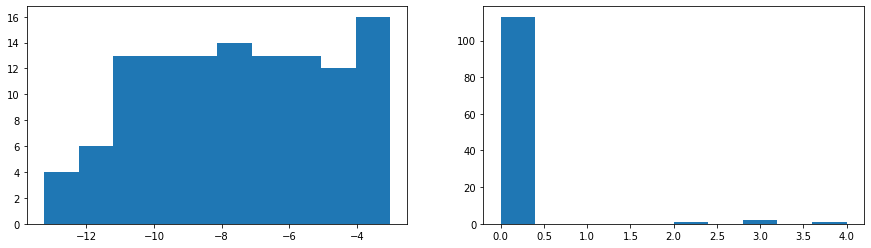

In [21]:
fig, axes = plt.subplots(ncols=2, figsize=(15, 4))

ax = axes[0]
ax.hist(np.log10((np.abs(eigenvals - eig_0)).flatten()))

ax = axes[1]
ax.hist(idx.flatten())

plt.show()

#### Eigenvalue variation

Eigenvalue grid for plotting analytical solution

In [22]:
Em_pred = np.logspace(np.log10(Em_list[0]), np.log10(Em_list[-1]), num=100)
Le_pred = np.logspace(np.log10(Le_list[0]), np.log10(Le_list[-1]), num=100)

##### All eigenvalues

C:\Users\gentle\AppData\Local\Temp\ipykernel_3920\581498140.py:16: RuntimeWarning: invalid value encountered in log10
  ax.scatter(np.log10(Le_mesh), np.log10(Em_mesh), np.log10(-np.real(eigendiff)))


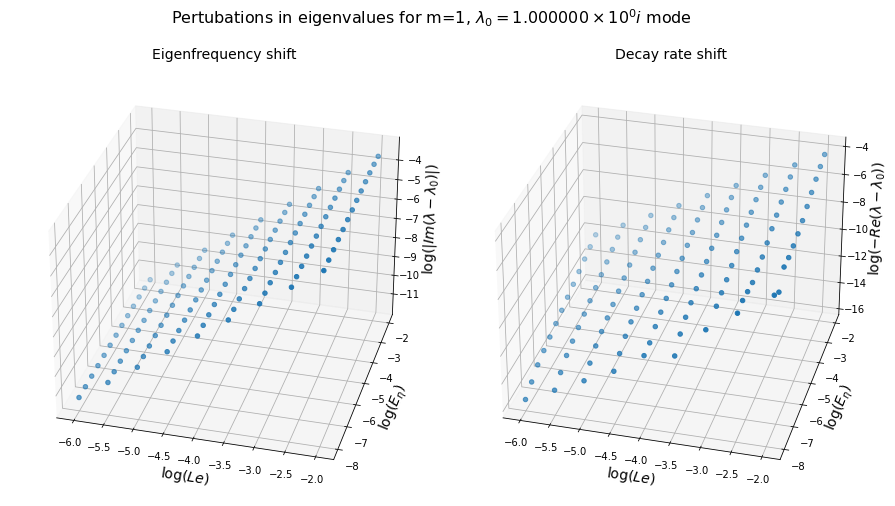

In [164]:
save_name = './runs/Axial_Le_Eeta_mesh/eigvals_spinover_Le_Eeta_3d'
# save_name = None
overwrite = False

fig = plt.figure(figsize=(18, 8))

ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.scatter(np.log10(Le_mesh), np.log10(Em_mesh), np.log10(np.sign(np.imag(eigendiff[0, 0]))*np.imag(eigendiff)))
ax.set_xlabel(r'$\log(Le)$', fontsize=14)
ax.set_ylabel(r'$\log(E_\eta)$', fontsize=14)
ax.set_zlabel(r'$\log(|Im(\lambda - \lambda_0)|)$', fontsize=14)
ax.view_init(elev=30, azim=-75, roll=0)
ax.set_title('Eigenfrequency shift', fontsize=14)

ax = fig.add_subplot(1, 2, 2, projection='3d')
ax.scatter(np.log10(Le_mesh), np.log10(Em_mesh), np.log10(-np.real(eigendiff)))
ax.set_xlabel(r'$\log(Le)$', fontsize=14)
ax.set_ylabel(r'$\log(E_\eta)$', fontsize=14)
ax.set_zlabel(r'$\log(-Re(\lambda - \lambda_0))$', fontsize=14)
ax.view_init(elev=30, azim=-75, roll=0)
ax.set_title('Decay rate shift', fontsize=14)

imag_dec = pgpy_utils.decimal_decomp(eig_0.imag)
fig.suptitle(r'Pertubations in eigenvalues for m=%d, $\lambda_0=%.6f\times10^{%d}i$ mode' % (m_val, *imag_dec,), fontsize=16)

plt.subplots_adjust(wspace=-0.2, hspace=0)
if save_name is not None:
    if os.path.exists(save_name + '.png') and not overwrite:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")
plt.show()

##### Fixed Lehnert number

- Quick check

In [23]:
i_Le = 2

print('Le = {:.3e}'.format(Le_list[i_Le]))
for i_Em, Em in enumerate(Em_list):
    print('Em = {:.3e} | lambda = {:.15e} | dlambda = {:.8e}'.format(Em_list[i_Em], eigenvals[i_Le, i_Em], eigendiff[i_Le, i_Em]))

Le = 1.000e-05
Em = 1.000e-08 | lambda = -2.054886306564733e-11-4.764063252206925e-02j | dlambda = -2.05488631e-11-1.24155655e-09j
Em = 3.162e-08 | lambda = -3.544783741236958e-11-4.764063250613310e-02j | dlambda = -3.54478374e-11-1.22562040e-09j
Em = 1.000e-07 | lambda = -6.110781712407642e-11-4.764063247752851e-02j | dlambda = -6.11078171e-11-1.19701581e-09j
Em = 3.162e-07 | lambda = -1.027869470050263e-10-4.764063242701654e-02j | dlambda = -1.02786947e-10-1.14650384e-09j
Em = 1.000e-06 | lambda = -1.653401735072171e-10-4.764063233902251e-02j | dlambda = -1.65340174e-10-1.05850981e-09j
Em = 3.162e-06 | lambda = -2.451125110509546e-10-4.764063219140956e-02j | dlambda = -2.45112511e-10-9.10896858e-10j
Em = 1.000e-05 | lambda = -3.133091650363093e-10-4.764063196676172e-02j | dlambda = -3.13309165e-10-6.86249016e-10j
Em = 3.162e-05 | lambda = -3.116149382675306e-10-4.764063169370839e-02j | dlambda = -3.11614938e-10-4.13195686e-10j
Em = 1.000e-04 | lambda = -2.275188655871543e-10-4.764063

In [24]:
for Em in Em_list:
    print('{:.8e}'.format(Le_list[i_Le]**2*(lambda_2_0 + lambda_2_1*np.sqrt(Em))))

-2.07367951e-11-1.24173486e-09j
-3.68758157e-11-1.22559584e-09j
-6.55755038e-11-1.19689615e-09j
-1.16611568e-10-1.14586009e-09j
-2.07367951e-10-1.05510371e-09j
-3.68758157e-10-8.93713501e-10j
-6.55755038e-10-6.06716620e-10j
-1.16611568e-09-9.63559760e-11j
-2.07367951e-09+8.11207849e-10j
-3.68758157e-09+2.42510991e-09j
-6.55755038e-09+5.29507872e-09j
-1.16611568e-08+1.03986852e-08j
-2.07367951e-08+1.94743234e-08j


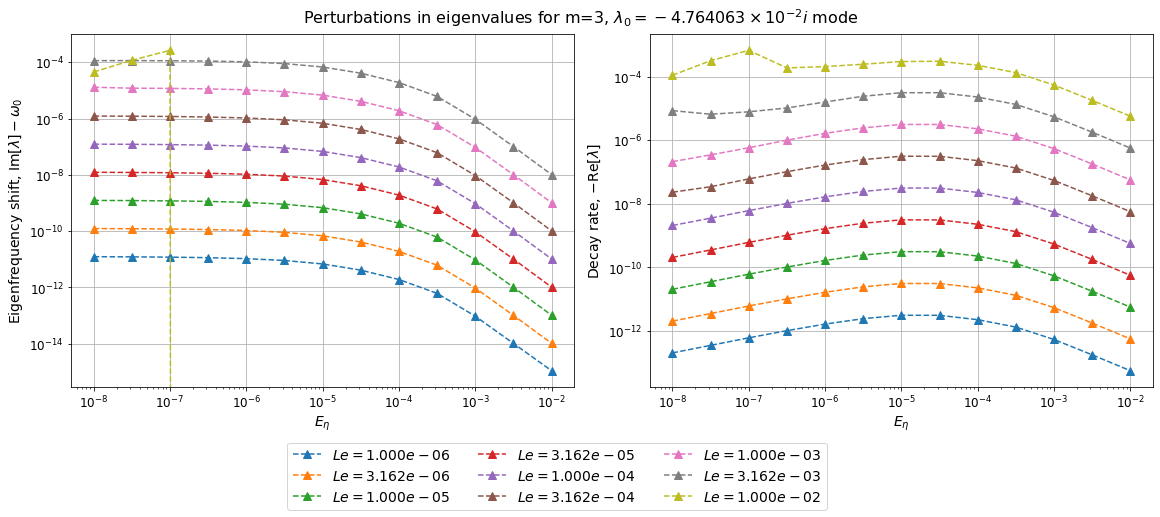

In [25]:
save_name = './runs/Axial_Le_Eeta_mesh/eigvals_spinover_fixedLe_all'
save_name = None
overwrite = False

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), layout='constrained')

plot_idx = np.arange(Le_list.size)
# plot_idx = [0,]

ax = axes[0]
for i_Le, Le in enumerate(Le_list[plot_idx]):
    ax.loglog(Em_list, np.sign(np.imag(eigendiff[i_Le, 0]))*np.imag(eigendiff[i_Le, :]), '^--', markersize=8, 
              label=r'$Le=%.3e$' % (Le,))
ax.grid(which='major')
ax.tick_params(which='major', labelsize=12)
ax.set_xlabel('$E_\eta$', fontsize=14)
ax.set_ylabel('Eigenfrequency shift, $\mathrm{Im}[\lambda] - \omega_0$', fontsize=14)
# ax.legend(fontsize=12)

ax = axes[1]
line_handles = list()
for i_Le, Le in enumerate(Le_list[plot_idx]):
    line = ax.loglog(Em_list, - np.real(eigendiff[i_Le, :]), '^--', markersize=8, label=r'$Le=%.3e$' % (Le,))
    line_handles.append(*line)
ax.grid(which='major')
ax.tick_params(which='major', labelsize=12)
ax.set_xlabel('$E_\eta$', fontsize=14)
ax.set_ylabel('Decay rate, $-\mathrm{Re}[\lambda]$', fontsize=14)
# ax.legend(fontsize=12)

real_dec = pgpy_utils.decimal_decomp(eig_0.real)
imag_dec = pgpy_utils.decimal_decomp(eig_0.imag)
# fig.suptitle(r'Meridional slice, $\lambda=%+.6f\times10^{%d}i$' % \
#     imag_dec, fontsize=16)
fig.suptitle(r'Perturbations in eigenvalues for m=%d, $\lambda_0=%.6f\times10^{%d}i$ mode' % (m_val, *imag_dec,), fontsize=16)
fig.legend(handles=line_handles, ncol=3, bbox_to_anchor=(0.72, 0.0), fontsize=14)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not overwrite:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")

plt.show()

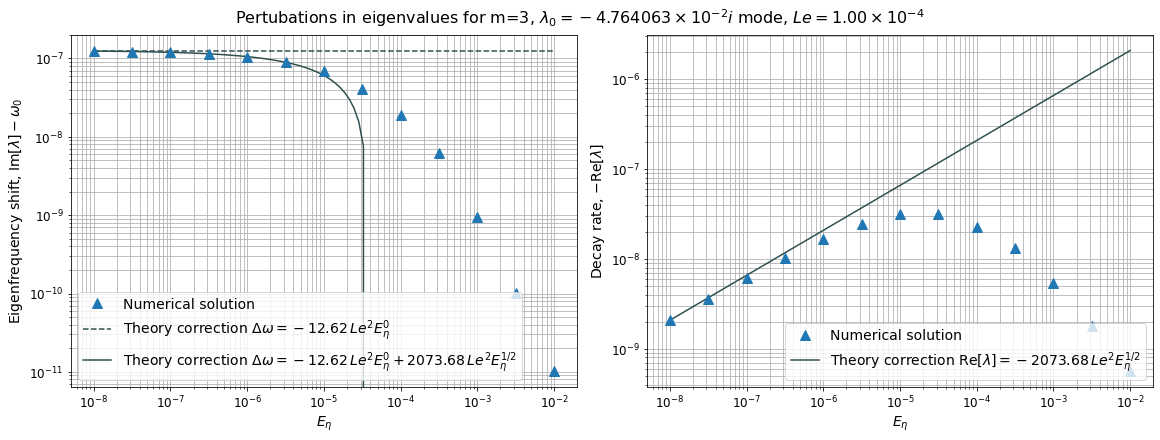

In [31]:
i_par_plot = 4
Le_val = Le_list[i_par_plot]
save_name = './runs/Axial_Le_Eeta_mesh/eigvals_spinover_fixedLe_{:.1e}_bl12'.format(Le_val)
save_name = None
overwrite = False

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), layout='constrained')

ax = axes[0]
sign = np.sign(np.imag(eigendiff[i_par_plot, 0]))
ax.plot(Em_list, sign*np.imag(eigendiff[i_par_plot, :]), '^', markersize=10, label='Numerical solution', zorder=5)
ax.plot(
    Em_pred, Le_val**2*sign*(np.imag(lambda_2_0)*np.ones_like(Em_pred)), 
    '--', color='darkslategray', 
    label='Theory correction $\\Delta\\omega=%.2f \, Le^2 E_\eta^0$' % (
        np.imag(lambda_2_0)
    )
)
ax.plot(
    Em_pred, Le_val**2*sign*(np.imag(lambda_2_0)*np.ones_like(Em_pred) + np.imag(lambda_2_1)*np.sqrt(Em_pred)), 
    '-', color='darkslategray', 
    label='Theory correction $\\Delta\\omega=%.2f \, Le^2 E_\eta^0 %+.2f \, Le^2 E_\eta^{1/2}$' % (
        np.imag(lambda_2_0), np.imag(lambda_2_1)
    )
)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(which='both')
ax.tick_params(which='both', labelsize=12)
ax.set_xlabel('$E_\eta$', fontsize=14)
ax.set_ylabel('Eigenfrequency shift, $\mathrm{Im}[\lambda] - \omega_0$', fontsize=14)
ax.legend(fontsize=14, loc=3)

ax = axes[1]
line_handles = list()
ax.loglog(Em_list, - np.real(eigendiff[i_par_plot, :]), '^', markersize=10, label='Numerical solution', zorder=5)
# ax.loglog(Em_list[1:-2], 0.8*(-np.real(eigendiff[i_par_plot, 4])/Em_list[4]**(1/2))*Em_list[1:-2]**(1/2), '-', 
#     color='darkslategray', label=r'Scaling $E_\eta^{1/2}$')
ax.loglog(
    Em_pred, -np.real(lambda_2_1)*Le_val**2*np.sqrt(Em_pred), '-', 
    color='darkslategray', 
    label='Theory correction $\\mathrm{Re}[\\lambda]=%+.2f \, Le^2 E_\eta^{1/2}$' % (
        np.real(lambda_2_1)
    )
)
ax.grid(which='both')
ax.tick_params(which='both', labelsize=12)
ax.set_xlabel('$E_\eta$', fontsize=14)
ax.set_ylabel('Decay rate, $-\mathrm{Re}[\lambda]$', fontsize=14)
ax.legend(fontsize=14, loc=4)

real_dec = pgpy_utils.decimal_decomp(eig_0.real)
imag_dec = pgpy_utils.decimal_decomp(eig_0.imag)
Le_dec = pgpy_utils.decimal_decomp(Le_val)
# fig.suptitle(r'Meridional slice, $\lambda=%+.6f\times10^{%d}i$' % \
#     imag_dec, fontsize=16)
fig.suptitle(r'Pertubations in eigenvalues for m=%d, $\lambda_0=%.6f\times10^{%d}i$ mode, $Le = %.2f\times10^{%d}$' % 
    (m_val, *imag_dec, *Le_dec), fontsize=16)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not overwrite:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")

plt.show()

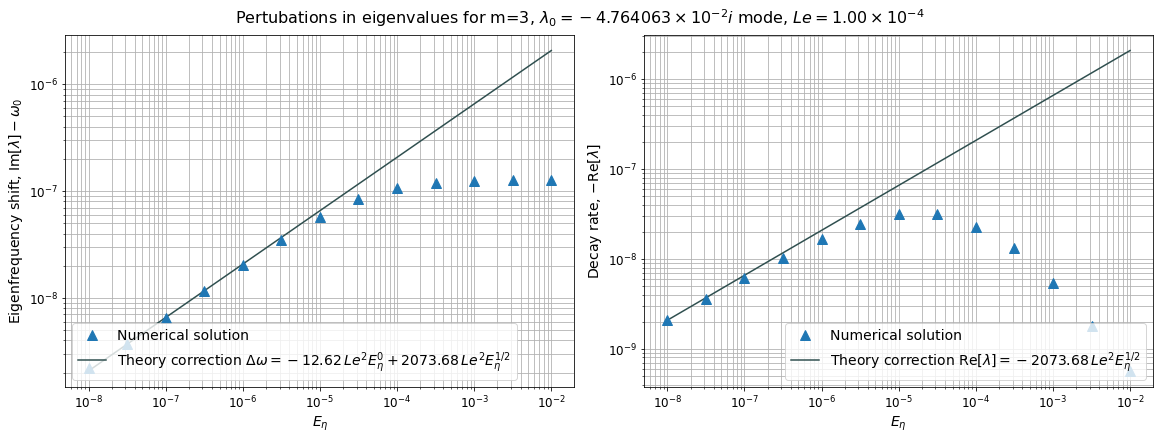

In [32]:
i_par_plot = 4
Le_val = Le_list[i_par_plot]
save_name = './runs/Axial_Le_Eeta_mesh/eigvals_spinover_fixedLe_{:.1e}_bl12'.format(Le_val)
save_name = None
overwrite = False

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), layout='constrained')

ax = axes[0]
sign = np.sign(np.imag(eigendiff[i_par_plot, 0]))
sign2 = np.sign(np.imag(eigendiff[i_par_plot, 0]) - Le_val**2*np.imag(lambda_2_0))
ax.plot(Em_list, sign2*(np.imag(eigendiff[i_par_plot, :]) - Le_val**2*(np.imag(lambda_2_0))), '^', markersize=10, label='Numerical solution', zorder=5)
ax.plot(
    Em_pred, Le_val**2*sign2*(np.imag(lambda_2_1)*np.sqrt(Em_pred)), 
    '-', color='darkslategray', 
    label='Theory correction $\\Delta\\omega=%.2f \, Le^2 E_\eta^0 %+.2f \, Le^2 E_\eta^{1/2}$' % (
        np.imag(lambda_2_0), np.imag(lambda_2_1)
    )
)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(which='both')
ax.tick_params(which='both', labelsize=12)
ax.set_xlabel('$E_\eta$', fontsize=14)
ax.set_ylabel('Eigenfrequency shift, $\mathrm{Im}[\lambda] - \omega_0$', fontsize=14)
ax.legend(fontsize=14, loc=3)

ax = axes[1]
line_handles = list()
ax.loglog(Em_list, - np.real(eigendiff[i_par_plot, :]), '^', markersize=10, label='Numerical solution', zorder=5)
# ax.loglog(Em_list[1:-2], 0.8*(-np.real(eigendiff[i_par_plot, 4])/Em_list[4]**(1/2))*Em_list[1:-2]**(1/2), '-', 
#     color='darkslategray', label=r'Scaling $E_\eta^{1/2}$')
ax.loglog(
    Em_pred, -np.real(lambda_2_1)*Le_val**2*np.sqrt(Em_pred), '-', 
    color='darkslategray', 
    label='Theory correction $\\mathrm{Re}[\\lambda]=%+.2f \, Le^2 E_\eta^{1/2}$' % (
        np.real(lambda_2_1)
    )
)
ax.grid(which='both')
ax.tick_params(which='both', labelsize=12)
ax.set_xlabel('$E_\eta$', fontsize=14)
ax.set_ylabel('Decay rate, $-\mathrm{Re}[\lambda]$', fontsize=14)
ax.legend(fontsize=14, loc=4)

real_dec = pgpy_utils.decimal_decomp(eig_0.real)
imag_dec = pgpy_utils.decimal_decomp(eig_0.imag)
Le_dec = pgpy_utils.decimal_decomp(Le_val)
# fig.suptitle(r'Meridional slice, $\lambda=%+.6f\times10^{%d}i$' % \
#     imag_dec, fontsize=16)
fig.suptitle(r'Pertubations in eigenvalues for m=%d, $\lambda_0=%.6f\times10^{%d}i$ mode, $Le = %.2f\times10^{%d}$' % 
    (m_val, *imag_dec, *Le_dec), fontsize=16)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not overwrite:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")

plt.show()

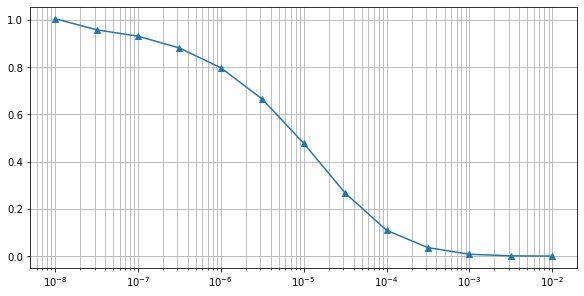

In [30]:
fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
ax.semilogx(Em_list, np.real(eigendiff[i_par_plot, :])/np.real(lambda_2_1*Le_val**2*np.sqrt(Em_list)), '^-')
ax.grid(which='both')
plt.show()

##### Fixed magnetic Ekman number

- Quick check

In [172]:
i_Em = 4

print('Em = {:.3e}'.format(Em_list[i_Em]))
for i_Le, Le in enumerate(Le_list):
    print('Le = {:.3e} | lambda = {:.15e} | dlambda = {:.8e}'.format(Le_list[i_Le], eigenvals[i_Le, i_Em], eigendiff[i_Le, i_Em]))

Em = 1.000e-06
Le = 1.000e-06 | lambda = -7.944243768886144e-15+1.000000000003742e+00j | dlambda = -7.94424377e-15+3.74211773e-12j
Le = 3.162e-06 | lambda = -7.944208215938753e-14+1.000000000037421e+00j | dlambda = -7.94420822e-14+3.74205111e-11j
Le = 1.000e-05 | lambda = -7.943853270183500e-13+1.000000000374204e+00j | dlambda = -7.94385327e-13+3.74204445e-10j
Le = 3.162e-05 | lambda = -7.940306226159160e-12+1.000000003742041e+00j | dlambda = -7.94030623e-12+3.74204112e-09j
Le = 1.000e-04 | lambda = -7.905080082291366e-11+1.000000037420044e+00j | dlambda = -7.90508008e-11+3.74200435e-08j
Le = 3.162e-04 | lambda = -7.590036974711871e-10+1.000000374160666e+00j | dlambda = -7.59003697e-10+3.74160666e-07j
Le = 1.000e-03 | lambda = -6.302969653260375e-09+1.000003737859883e+00j | dlambda = -6.30296965e-09+3.73785988e-06j
Le = 3.162e-03 | lambda = -5.913224130262764e-08+1.000037196682639e+00j | dlambda = -5.91322413e-08+3.71966826e-05j
Le = 1.000e-02 | lambda = -8.123144692166426e-07+1.000365

In [173]:
for Le in Le_list:
    print('{:.8e}'.format(Le**2*(lambda_2_0 + lambda_2_1*np.sqrt(Em_list[i_Em]))))

-7.95495129e-15+3.74204505e-12j
-7.95495129e-14+3.74204505e-11j
-7.95495129e-13+3.74204505e-10j
-7.95495129e-12+3.74204505e-09j
-7.95495129e-11+3.74204505e-08j
-7.95495129e-10+3.74204505e-07j
-7.95495129e-09+3.74204505e-06j
-7.95495129e-08+3.74204505e-05j
-7.95495129e-07+3.74204505e-04j


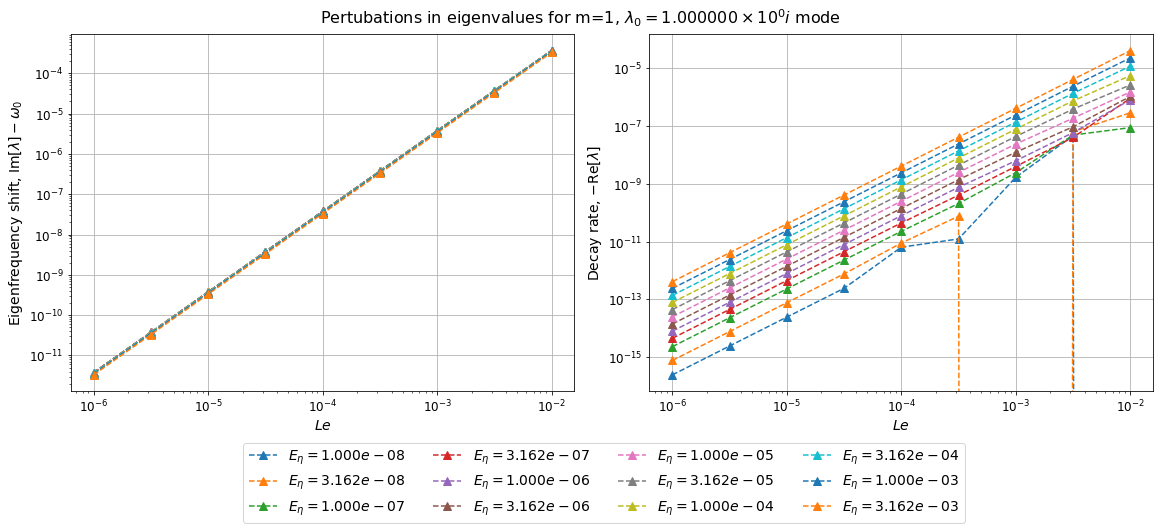

In [175]:
save_name = './runs/Axial_Le_Eeta_mesh/eigvals_spinover_fixedEm_all'
# save_name = None
overwrite = False

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), layout='constrained')

plot_idx = np.arange(Em_list.size-1)
# plot_idx = [0,]

ax = axes[0]
for i_Em, Em in enumerate(Em_list[plot_idx]):
    ax.loglog(Le_list, np.sign(np.imag(eigendiff[0, 0]))*np.imag(eigendiff[:, i_Em]), '^--', markersize=8, 
              label=r'$E_\eta=%.3e$' % (Em,))
ax.grid(which='major')
ax.tick_params(which='major', labelsize=12)
ax.set_xlabel('$Le$', fontsize=14)
ax.set_ylabel('Eigenfrequency shift, $\mathrm{Im}[\lambda] - \omega_0$', fontsize=14)
# ax.legend(fontsize=12)

ax = axes[1]
line_handles = list()
for i_Em, Em in enumerate(Em_list[plot_idx]):
    line = ax.loglog(Le_list, - np.real(eigendiff[:, i_Em]), '^--', markersize=8, label=r'$E_\eta=%.3e$' % (Em,))
    line_handles.append(*line)
ax.grid(which='major')
ax.tick_params(which='major', labelsize=12)
ax.set_xlabel('$Le$', fontsize=14)
ax.set_ylabel('Decay rate, $-\mathrm{Re}[\lambda]$', fontsize=14)
# ax.legend(fontsize=12)

real_dec = pgpy_utils.decimal_decomp(eig_0.real)
imag_dec = pgpy_utils.decimal_decomp(eig_0.imag)
# fig.suptitle(r'Meridional slice, $\lambda=%+.6f\times10^{%d}i$' % \
#     imag_dec, fontsize=16)
fig.suptitle(r'Pertubations in eigenvalues for m=%d, $\lambda_0=%.6f\times10^{%d}i$ mode' % (m_val, *imag_dec,), fontsize=16)
fig.legend(handles=line_handles, ncol=4, bbox_to_anchor=(0.84, 0.0), fontsize=14)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not overwrite:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")

plt.show()

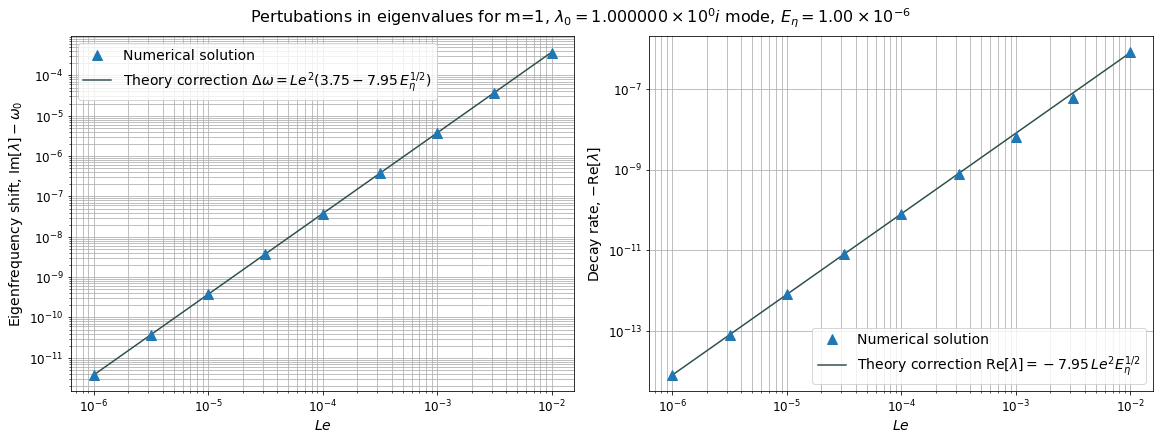

In [177]:
i_par_plot = 4
Em_val = Em_list[i_par_plot]
save_name = './runs/Axial_Le_Eeta_mesh/eigvals_spinover_fixedEm_{:.1e}_bl2'.format(Em_val)
# save_name = None
overwrite = True

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), layout='constrained')

ax = axes[0]
sign = np.sign(np.imag(eigendiff[0, 0]))
ax.loglog(Le_list, sign*np.imag(eigendiff[:, i_par_plot]), '^', markersize=10, label='Numerical solution', zorder=5)
# ax.loglog(Le_list, Le_list**2*sign*np.imag(lambda_2_0), 
#     '-', color='darkslategray', label='Theory correction $\\Delta\\omega=%.2f \, Le^2 E_\eta^0$' % (np.imag(lambda_2_0),))
ax.loglog(
    Le_pred, Le_pred**2*sign*(np.imag(lambda_2_0)), 
    '-', color='darkslategray', 
    label='Theory correction $\\Delta\\omega=Le^2 (%.2f %+.2f \, E_\eta^{1/2})$' % (
        np.imag(lambda_2_0), np.imag(lambda_2_1)
    )
)
ax.grid(which='both')
ax.tick_params(which='both', labelsize=12)
ax.set_xlabel('$Le$', fontsize=14)
ax.set_ylabel('Eigenfrequency shift, $\mathrm{Im}[\lambda] - \omega_0$', fontsize=14)
ax.legend(fontsize=14, loc=2)

ax = axes[1]
line_handles = list()
ax.loglog(Le_list, - np.real(eigendiff[:, i_par_plot]), '^', markersize=10, label='Numerical solution', zorder=5)
# ax.loglog(Le_list, 0.8*(-np.real(eigendiff[2, i_par_plot])/Le_list[2]**2)*Le_list**2, '-', 
#     color='darkslategray', label=r'Scaling $Le^2$')
ax.loglog(
    Le_pred, -np.real(lambda_2_1)*Le_pred**2*np.sqrt(Em_val), '-', 
    color='darkslategray', 
    label='Theory correction $\\mathrm{Re}[\\lambda]=%+.2f \, Le^2 E_\eta^{1/2}$' % (
        np.real(lambda_2_1)
    )
)
ax.grid(which='both')
ax.tick_params(which='both', labelsize=12)
ax.set_xlabel('$Le$', fontsize=14)
ax.set_ylabel('Decay rate, $-\mathrm{Re}[\lambda]$', fontsize=14)
ax.legend(fontsize=14, loc=4)

real_dec = pgpy_utils.decimal_decomp(eig_0.real)
imag_dec = pgpy_utils.decimal_decomp(eig_0.imag)
Em_dec = pgpy_utils.decimal_decomp(Em_val)
# fig.suptitle(r'Meridional slice, $\lambda=%+.6f\times10^{%d}i$' % \
#     imag_dec, fontsize=16)
fig.suptitle(r'Pertubations in eigenvalues for m=%d, $\lambda_0=%.6f\times10^{%d}i$ mode, $E_\eta = %.2f\times10^{%d}$' % 
    (m_val, *imag_dec, *Em_dec), fontsize=16)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not overwrite:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")

plt.show()

#### Overall visualisation

In [137]:
nr, maxnl, m_val = 93, 93, 3
Nr = 201
Nt = 201

rg = specfun.roots_chebyt(Nr*2 - (Nr % 2))[0][-Nr:]
tg = np.linspace(0, np.pi, Nt)
rr, tt = np.meshgrid(rg, tg)
X1, X2 = rr*np.sin(tt), rr*np.cos(tt)

worland_transform = WorlandTransform(nr, maxnl, m_val, r_grid=rg)
plm_transform = AssociatedLegendreTransformSingleM(maxnl, m_val, tg)

In [138]:
i_Le = 4
i_Em = 4

Ndim = eigenvecs.shape[-1]
usp = VectorFieldSingleM(nr, maxnl, m_val, eigenvecs[i_Le, i_Em, :Ndim//2])
bsp = VectorFieldSingleM(nr, maxnl, m_val, eigenvecs[i_Le, i_Em, Ndim//2:])
u_sph = usp.physical_field(worland_transform, plm_transform).data
b_sph = bsp.physical_field(worland_transform, plm_transform).data

max_id = np.unravel_index(np.argmax(np.abs(u_sph['phi'])), u_sph['phi'].shape)
max_phi_val = np.max(np.abs(u_sph['phi']))
arg_0 = -np.angle(u_sph['phi'][max_id])
for comp in u_sph:
    u_sph[comp] *= np.exp(1j*arg_0)/max_phi_val
    b_sph[comp] *= np.exp(1j*arg_0)/max_phi_val

u0_sph_val = [
    np.ones_like(rr)*sym.lambdify([m_inert.r, m_inert.theta], u_comp.subs(parsub), modules=['numpy', 'scipy'])(rr, tt) for u_comp in u0_sph
]
b1_in_sph_val = [
    Le_list[i_Le]*np.ones_like(rr)*sym.lambdify([m_inert.r, m_inert.theta], b_comp.subs(parsub), modules=['numpy', 'scipy'])(rr, tt) for b_comp in b1_in_sph
]
max_int_id = np.argmax(np.abs(u0_sph_val[2]).flatten())
max_int_val = u0_sph_val[2].flatten()[max_int_id]
for comp in range(len(u0_sph_val)):
    u0_sph_val[comp] /= max_int_val
    b1_in_sph_val[comp] /= max_int_val
    
fields = {
    'v0_r': u0_sph_val[0], 
    'v0_t': u0_sph_val[1],
    'v0_p': u0_sph_val[2], 
    'v0_s': (u0_sph_val[0]*np.sin(tt) + u0_sph_val[1]*np.cos(tt)), 
    'v0_z': (u0_sph_val[0]*np.cos(tt) - u0_sph_val[1]*np.sin(tt)),
    'v_r': u_sph['r'], 
    'v_t': u_sph['theta'],
    'v_p': u_sph['phi'], 
    'v_s': (u_sph['r']*np.sin(tt) + u_sph['theta']*np.cos(tt)), 
    'v_z': (u_sph['r']*np.cos(tt) - u_sph['theta']*np.sin(tt)),
    'b_r': b_sph['r'], 
    'b_t': b_sph['theta'],
    'b_p': b_sph['phi'], 
    'b_s': (b_sph['r']*np.sin(tt) + b_sph['theta']*np.cos(tt)), 
    'b_z': (b_sph['r']*np.cos(tt) - b_sph['theta']*np.sin(tt)),
    'b1_in_r': b1_in_sph_val[0], 
    'b1_in_t': b1_in_sph_val[1],
    'b1_in_p': b1_in_sph_val[2], 
    'b1_in_s': (b1_in_sph_val[0]*np.sin(tt) + b1_in_sph_val[1]*np.cos(tt)), 
    'b1_in_z': (b1_in_sph_val[0]*np.cos(tt) - b1_in_sph_val[1]*np.sin(tt)),
}

<lambdifygenerated-127>:2: RuntimeWarning: invalid value encountered in true_divide
  return 0.978302042870376016*1j*((1j*r*(-180.212535299783076*r**5*sin(Dummy_165)**5 + 653.84267003416243*r**5*sin(Dummy_165)**3*cos(Dummy_165)**2 + 508.492508537773649*r**5*sin(Dummy_165)*cos(Dummy_165)**4 - 192.546584490423568*r**3*sin(Dummy_165)**3 - 898.459218816051911*r**3*sin(Dummy_165)*cos(Dummy_165)**2 + 156.344137345139476*r*sin(Dummy_165))*sin(Dummy_165) + 1j*(-30.0354225499638459*r**6*sin(Dummy_165)**6 + 163.460667508540607*r**6*sin(Dummy_165)**4*cos(Dummy_165)**2 + 254.246254268886825*r**6*sin(Dummy_165)**2*cos(Dummy_165)**4 - 48.1366461226058921*r**4*sin(Dummy_165)**4 - 449.229609408025956*r**4*sin(Dummy_165)**2*cos(Dummy_165)**2 + 78.1720686725697381*r**2*sin(Dummy_165)**2))/(r*sin(Dummy_165)) - 3*1j*(284.258741744955329*r**6*sin(Dummy_165)**6 + 1274.70846472179822*r**6*sin(Dummy_165)**4*cos(Dummy_165)**2 + 254.246254268886825*r**6*sin(Dummy_165)**2*cos(Dummy_165)**4 - 375.381987673563535*

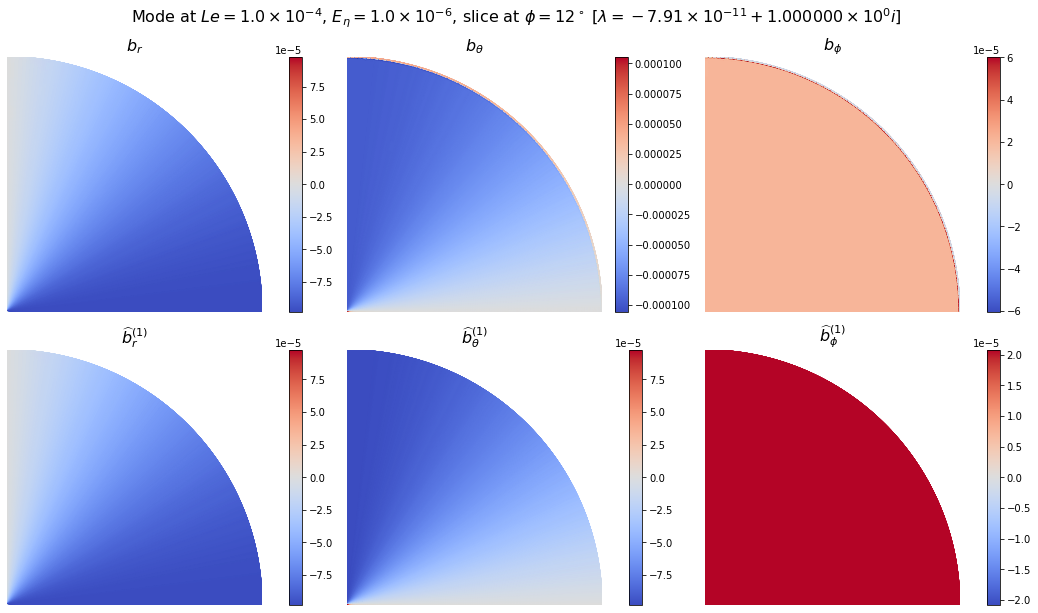

In [315]:
lon_view = 12
save_name = "./runs/Axial_Le_Eeta_mesh/v_md_ie01_u_compare_v2"
save_name = None
override = False

plot_fields = [
    # ['v_s', 'v_z', 'v_p'],
    # ['v0_s', 'v0_z', 'v0_p'],
    # ['v_r', 'v_t', 'v_p'],
    ["b_r", "b_t", "b_p"],
    ["b1_in_r", "b1_in_t", "b1_in_p"],
]
plot_fnames = [
    # [r"$v_s$", r"$v_z$", r"$v_\phi$"],
    # [r"$v_{0s}$", r"$v_{0z}$", r"$v_{0\phi}$"],
    # [r"$v_r$", r"$v_\theta$", r"$v_\phi$"],
    [r"$b_r$", r"$b_\theta$", r"$b_\phi$"],
    [r"$\widehat{b}_r^{(1)}$", r"$\widehat{b}_\theta^{(1)}$", r"$\widehat{b}_\phi^{(1)}$"],
]

force_symmetric_cmap = True
phase = np.exp(1j*m_val*np.radians(lon_view))
norm = np.max(np.abs(fields['v_p']))
nrows, ncols = len(plot_fields), len(plot_fields[0])
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*4.8, nrows*4.2), layout='constrained')
axes = np.atleast_2d(axes)

for i_r in range(nrows):
    for i_c in range(ncols):
        fname = plot_fields[i_r][i_c]
        ax = axes[i_r][i_c]
        if fname is None:
            ax.remove()
            continue
        field_plot = np.real(fields[fname]*phase)/norm
        if np.abs(field_plot).max() > 1e-7:
            if force_symmetric_cmap:
                climit = np.max(np.abs(field_plot))
                # climit = 0.7
                cm = ax.pcolormesh(X1, X2, field_plot, shading="gouraud", cmap="coolwarm", vmin=-climit, vmax=+climit)
                plt.colorbar(cm, ax=ax)
            else:
                cm = ax.pcolormesh(X1, X2, field_plot, shading="gouraud", cmap="coolwarm")
                plt.colorbar(cm, ax=ax)
        else:
            cm = ax.pcolormesh(X1, X2, field_plot, shading="gouraud", cmap="coolwarm", vmin=-1e-7, vmax=+1e-7)
            plt.colorbar(cm, ax=ax)
        
        ax.set_title(plot_fnames[i_r][i_c], fontsize=16)
        ax.set_aspect('equal', 'box')
        # ax.grid()
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.axis("off")

real_dec = pgpy_utils.decimal_decomp(eigenvals[i_Le, i_Em].real)
imag_dec = pgpy_utils.decimal_decomp(eigenvals[i_Le, i_Em].imag)
Le_dec = pgpy_utils.decimal_decomp(Le_list[i_Le])
Em_dec = pgpy_utils.decimal_decomp(Em_list[i_Em])
fig.suptitle(
    r'Mode at $Le=%.1f\times10^{%d}$, $E_\eta=%.1f\times10^{%d}$, slice at $\phi=%.0f^\circ$ [$\lambda=%+.2f\times10^{%d}%+.6f\times10^{%d}i$]' % \
    (*Le_dec, *Em_dec, lon_view, *real_dec, *imag_dec), fontsize=16)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not override:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")

plt.show()

#### Radial profile at a latitude

In [139]:
Nr = 201
cla = np.radians(75)

rg = specfun.roots_chebyt(Nr*2 - (Nr % 2))[0][-Nr:]
tpt = np.array([cla])

worland_transform = WorlandTransform(nr, maxnl, m_val, r_grid=rg)
plm_transform = AssociatedLegendreTransformSingleM(maxnl, m_val, tpt)

<lambdifygenerated-145>:2: RuntimeWarning: invalid value encountered in true_divide
  return 0.978302042870376016*1j*((1j*r*(-180.212535299783076*r**5*sin(Dummy_183)**5 + 653.84267003416243*r**5*sin(Dummy_183)**3*cos(Dummy_183)**2 + 508.492508537773649*r**5*sin(Dummy_183)*cos(Dummy_183)**4 - 192.546584490423568*r**3*sin(Dummy_183)**3 - 898.459218816051911*r**3*sin(Dummy_183)*cos(Dummy_183)**2 + 156.344137345139476*r*sin(Dummy_183))*sin(Dummy_183) + 1j*(-30.0354225499638459*r**6*sin(Dummy_183)**6 + 163.460667508540607*r**6*sin(Dummy_183)**4*cos(Dummy_183)**2 + 254.246254268886825*r**6*sin(Dummy_183)**2*cos(Dummy_183)**4 - 48.1366461226058921*r**4*sin(Dummy_183)**4 - 449.229609408025956*r**4*sin(Dummy_183)**2*cos(Dummy_183)**2 + 78.1720686725697381*r**2*sin(Dummy_183)**2))/(r*sin(Dummy_183)) - 3*1j*(284.258741744955329*r**6*sin(Dummy_183)**6 + 1274.70846472179822*r**6*sin(Dummy_183)**4*cos(Dummy_183)**2 + 254.246254268886825*r**6*sin(Dummy_183)**2*cos(Dummy_183)**4 - 375.381987673563535*

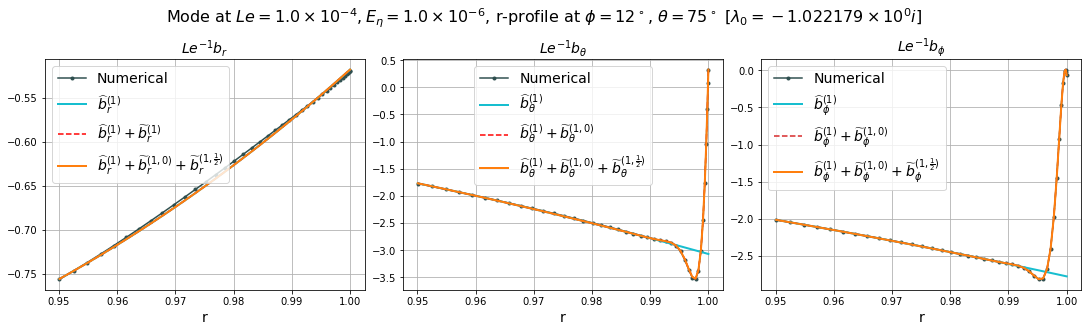

In [144]:
i_Le, i_Em = 4, 4
Le_val, Em_val = Le_list[i_Le], Em_list[i_Em]
r_min = 0.95
lon_view = 12
plot_BL = True

save_name = "./runs/Axial_Le_Eeta_mesh/profile_b_ie01_lat15_part_BL2"
# save_name = None
override = False

i_rg = rg > r_min
num_marker = '.-' if r_min >= 0.8 else '-'

phase = np.exp(1j*m_val*np.radians(lon_view))

Ndim = eigenvecs.shape[-1]
u_prof = VectorFieldSingleM(nr, maxnl, m_val, eigenvecs[i_Le, i_Em, :Ndim//2]).physical_field(worland_transform, plm_transform).data
b_prof = VectorFieldSingleM(nr, maxnl, m_val, eigenvecs[i_Le, i_Em, Ndim//2:]).physical_field(worland_transform, plm_transform).data
for comp in u_prof:
    u_prof[comp] = np.squeeze(u_prof[comp])*np.exp(1j*arg_0)*phase/max_phi_val
    b_prof[comp] = np.squeeze(b_prof[comp])*np.exp(1j*arg_0)*phase/max_phi_val/Le_val

u0_prof = [
    np.ones_like(rg)*sym.lambdify([m_inert.r, m_inert.theta], u_comp.subs(parsub), modules=['numpy', 'scipy'])(rg, tpt[0]) for u_comp in u0_sph
]
b1_in_prof = [
    Le_list[i_Le]*np.ones_like(rg)*sym.lambdify([m_inert.r, m_inert.theta], b_comp.subs(parsub), modules=['numpy', 'scipy'])(rg, tpt[0]) for b_comp in b1_in_sph
]
t_bl = np.sqrt(2*Em_list[i_Em]/np.abs(float(sym.im(lambda_0))))
b1_bl_prof = [
    np.zeros_like(rg),
    Le_val*np.squeeze(f_b1t_bl(tpt))*np.exp(-(1 + np.sign(np.imag(complex(lambda_0)))*1j)*(1 - rg)/t_bl),
    Le_val*np.squeeze(f_b1p_bl(tpt))*np.exp(-(1 + np.sign(np.imag(complex(lambda_0)))*1j)*(1 - rg)/t_bl)
]
b1_blh_prof = [
    Le_val*np.sqrt(Em_val)*np.squeeze(f_b1hr_bl0(tpt))*np.exp(-(1 + np.sign(np.imag(complex(lambda_0)))*1j)*(1 - rg)/t_bl),
    Le_val*np.sqrt(Em_val)*np.squeeze(f_b1ht_bl1(tpt)*(1 - rg)/np.sqrt(Em_val) + f_b1ht_bl0(tpt))*np.exp(-(1 + np.sign(np.imag(complex(lambda_0)))*1j)*(1 - rg)/t_bl),
    Le_val*np.sqrt(Em_val)*np.squeeze(f_b1hp_bl1(tpt)*(1 - rg)/np.sqrt(Em_val) + f_b1hp_bl0(tpt))*np.exp(-(1 + np.sign(np.imag(complex(lambda_0)))*1j)*(1 - rg)/t_bl)
]
for comp in range(len(u0_prof)):
    u0_prof[comp] = u0_prof[comp]*(phase/max_int_val)
    b1_in_prof[comp] = b1_in_prof[comp]*(phase/max_int_val)/Le_val
    b1_bl_prof[comp] = b1_bl_prof[comp]*(phase/max_int_val)/Le_val
    b1_blh_prof[comp] = b1_blh_prof[comp]*(phase/max_int_val)/Le_val

profiles = {
    'v_r': u_prof['r'], 'v_t': u_prof['theta'], 'v_p': u_prof['phi'],
    'b_r': b_prof['r'], 'b_t': b_prof['theta'], 'b_p': b_prof['phi'],
    'v0_r': u0_prof[0], 'v0_t': u0_prof[1], 'v0_p': u0_prof[2],
    'b1_in_r': b1_in_prof[0], 'b1_in_t': b1_in_prof[1], 'b1_in_p': b1_in_prof[2],
    'b1_bl_r': b1_bl_prof[0], 'b1_bl_t': b1_bl_prof[1], 'b1_bl_p': b1_bl_prof[2],
    'b1_blh_r': b1_blh_prof[0], 'b1_blh_t': b1_blh_prof[1], 'b1_blh_p': b1_blh_prof[2],
}

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(3*5, 4.5), layout='constrained')

ax = axes[0]
ax.plot(rg[i_rg], np.real(profiles['b_r'][i_rg]), num_marker, color='darkslategray', label='Numerical')
ax.plot(rg[i_rg], np.real(profiles['b1_in_r'][i_rg]), '-', color='tab:cyan', linewidth=2, label=r'$\widehat{b}_r^{(1)}$')
if plot_BL:
    ax.plot(rg[i_rg], np.real(profiles['b1_in_r'][i_rg]), '--', color='red', label=r'$\widehat{b}_r^{(1)} + \widetilde{b}_r^{(1)}$')
    ax.plot(rg[i_rg], np.real(profiles['b1_in_r'][i_rg] + profiles['b1_blh_r'][i_rg]), 
        '-', color='tab:orange', linewidth=2,
        label=r'$\widehat{b}_r^{(1)} + \widetilde{b}_r^{(1,0)} + \widetilde{b}_r^{(1,\frac{1}{2})}$')
ax.grid(which='both')
ax.legend(fontsize=14)
ax.set_xlabel('r', fontsize=14)
ax.set_title('$Le^{-1}b_r$', fontsize=14)

ax = axes[1]
ax.plot(rg[i_rg], np.real(profiles['b_t'][i_rg]), num_marker, color='darkslategray', label='Numerical')
ax.plot(rg[i_rg], np.real(profiles['b1_in_t'][i_rg]), '-', color='tab:cyan', linewidth=2,
    label=r'$\widehat{b}_\theta^{(1)}$')
if plot_BL:
    ax.plot(rg[i_rg], np.real(profiles['b1_in_t'][i_rg] + profiles['b1_bl_t'][i_rg]), '--', color='red',
        label=r'$\widehat{b}_\theta^{(1)} + \widetilde{b}_\theta^{(1,0)}$')
    ax.plot(rg[i_rg], np.real(profiles['b1_in_t'][i_rg] + profiles['b1_bl_t'][i_rg] + profiles['b1_blh_t'][i_rg]), 
        '-', color='tab:orange', linewidth=2,
        label=r'$\widehat{b}_\theta^{(1)} + \widetilde{b}_\theta^{(1,0)} + \widetilde{b}_\theta^{(1,\frac{1}{2})}$')
ax.grid(which='both')
ax.legend(fontsize=14)
ax.set_xlabel('r', fontsize=14)
ax.set_title(r'$Le^{-1}b_\theta$', fontsize=14)

ax = axes[2]
ax.plot(rg[i_rg], np.real(profiles['b_p'][i_rg]), num_marker, color='darkslategray', label='Numerical')
ax.plot(rg[i_rg], np.real(profiles['b1_in_p'][i_rg]), '-', color='tab:cyan', linewidth=2,
    label=r'$\widehat{b}_\phi^{(1)}$')
if plot_BL:
    ax.plot(rg[i_rg], np.real(profiles['b1_in_p'][i_rg] + profiles['b1_bl_p'][i_rg]), '--', color='tab:red', 
        label=r'$\widehat{b}_\phi^{(1)} + \widetilde{b}_\phi^{(1,0)}$')
    ax.plot(rg[i_rg], np.real(profiles['b1_in_p'][i_rg] + profiles['b1_bl_p'][i_rg] + profiles['b1_blh_p'][i_rg]), 
        '-', color='tab:orange', linewidth=2,
        label=r'$\widehat{b}_\phi^{(1)} + \widetilde{b}_\phi^{(1,0)} + \widetilde{b}_\phi^{(1,\frac{1}{2})}$')
ax.grid(which='both')
ax.legend(fontsize=14)
ax.set_xlabel('r', fontsize=14)
ax.set_title(r'$Le^{-1}b_\phi$', fontsize=14)

real_dec = pgpy_utils.decimal_decomp(float(sym.re(lambda_0)))
imag_dec = pgpy_utils.decimal_decomp(float(sym.im(lambda_0)))
Le_dec = pgpy_utils.decimal_decomp(Le_val)
Em_dec = pgpy_utils.decimal_decomp(Em_val)
fig.suptitle(r'Mode at $Le=%.1f\times10^{%d}, E_\eta=%.1f\times10^{%d}$, r-profile at $\phi=%.0f^\circ$, $\theta=%.0f^\circ$ [$\lambda_0=%+.6f\times10^{%d}i$]' 
    % (*Le_dec, *Em_dec, lon_view, np.degrees(cla), *imag_dec), fontsize=16)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not override:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")
        plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")

plt.show()

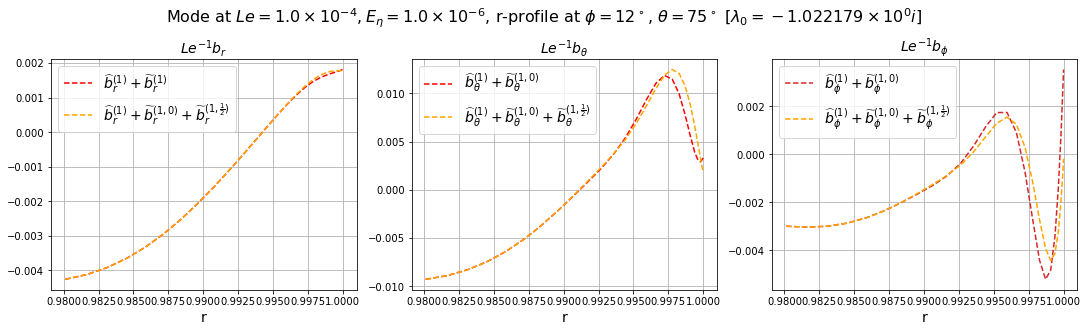

In [143]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(3*5, 4.5), layout='constrained')

ax = axes[0]
# ax.plot(rg[i_rg], np.real(profiles['b1_in_r'][i_rg] - profiles['b_r'][i_rg]), '-', color='tab:cyan', linewidth=2, label=r'$\widehat{b}_r^{(1)}$')
if plot_BL:
    ax.plot(rg[i_rg], np.real(profiles['b1_in_r'][i_rg] - profiles['b_r'][i_rg]), '--', color='red', label=r'$\widehat{b}_r^{(1)} + \widetilde{b}_r^{(1)}$')
    ax.plot(rg[i_rg], np.real(profiles['b1_in_r'][i_rg] + profiles['b1_blh_r'][i_rg] - profiles['b_r'][i_rg]), 
        '--', color='orange',
        label=r'$\widehat{b}_r^{(1)} + \widetilde{b}_r^{(1,0)} + \widetilde{b}_r^{(1,\frac{1}{2})}$')
ax.grid(which='both')
ax.legend(fontsize=14)
ax.set_xlabel('r', fontsize=14)
ax.set_title('$Le^{-1}b_r$', fontsize=14)

ax = axes[1]
# ax.plot(rg[i_rg], np.real(profiles['b1_in_t'][i_rg] - profiles['b_t'][i_rg]), '-', color='tab:cyan', linewidth=2,
#     label=r'$\widehat{b}_\theta^{(1)}$')
if plot_BL:
    ax.plot(rg[i_rg], np.real(profiles['b1_in_t'][i_rg] + profiles['b1_bl_t'][i_rg] - profiles['b_t'][i_rg]), '--', color='red',
        label=r'$\widehat{b}_\theta^{(1)} + \widetilde{b}_\theta^{(1,0)}$')
    ax.plot(rg[i_rg], np.real(profiles['b1_in_t'][i_rg] + profiles['b1_bl_t'][i_rg] + profiles['b1_blh_t'][i_rg] - profiles['b_t'][i_rg]), 
        '--', color='orange',
        label=r'$\widehat{b}_\theta^{(1)} + \widetilde{b}_\theta^{(1,0)} + \widetilde{b}_\theta^{(1,\frac{1}{2})}$')
ax.grid(which='both')
ax.legend(fontsize=14)
ax.set_xlabel('r', fontsize=14)
ax.set_title(r'$Le^{-1}b_\theta$', fontsize=14)

ax = axes[2]
# ax.plot(rg[i_rg], np.real(profiles['b1_in_p'][i_rg] - profiles['b_p'][i_rg]), '-', color='tab:cyan', linewidth=2,
#     label=r'$\widehat{b}_\phi^{(1)}$')
if plot_BL:
    ax.plot(rg[i_rg], np.real(profiles['b1_in_p'][i_rg] + profiles['b1_bl_p'][i_rg] - profiles['b_p'][i_rg]), '--', color='tab:red', 
        label=r'$\widehat{b}_\phi^{(1)} + \widetilde{b}_\phi^{(1,0)}$')
    ax.plot(rg[i_rg], np.real(profiles['b1_in_p'][i_rg] + profiles['b1_bl_p'][i_rg] + profiles['b1_blh_p'][i_rg] - profiles['b_p'][i_rg]), 
        '--', color='orange',
        label=r'$\widehat{b}_\phi^{(1)} + \widetilde{b}_\phi^{(1,0)} + \widetilde{b}_\phi^{(1,\frac{1}{2})}$')
ax.grid(which='both')
ax.legend(fontsize=14)
ax.set_xlabel('r', fontsize=14)
ax.set_title(r'$Le^{-1}b_\phi$', fontsize=14)

real_dec = pgpy_utils.decimal_decomp(float(sym.re(lambda_0)))
imag_dec = pgpy_utils.decimal_decomp(float(sym.im(lambda_0)))
Le_dec = pgpy_utils.decimal_decomp(Le_val)
Em_dec = pgpy_utils.decimal_decomp(Em_val)
fig.suptitle(r'Mode at $Le=%.1f\times10^{%d}, E_\eta=%.1f\times10^{%d}$, r-profile at $\phi=%.0f^\circ$, $\theta=%.0f^\circ$ [$\lambda_0=%+.6f\times10^{%d}i$]' 
    % (*Le_dec, *Em_dec, lon_view, np.degrees(cla), *imag_dec), fontsize=16)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not override:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")
        plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")

plt.show()

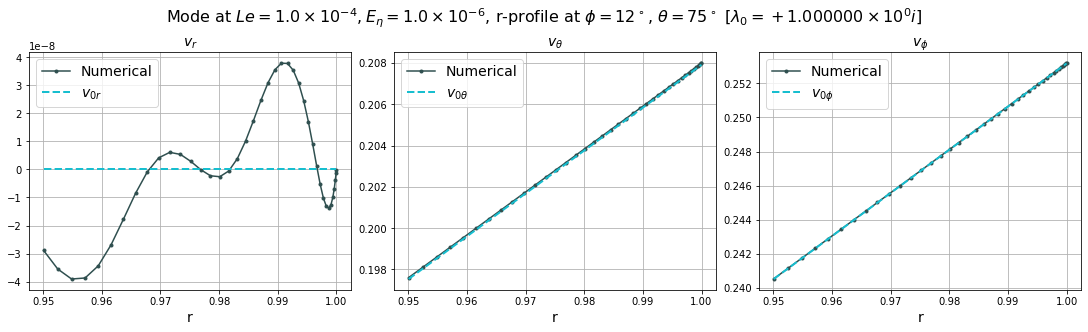

In [ ]:
i_Le, i_Em = 4, 4
Le_val, Em_val = Le_list[i_Le], Em_list[i_Em]
r_min = 0.95
lon_view = 12

save_name = "./runs/Axial_Le_Eeta_mesh/profile_v_iw03_lat15_part"
save_name = None
override = False

i_rg = rg > r_min
num_marker = '.-' if r_min >= 0.8 else '-'

phase = np.exp(1j*m_val*np.radians(lon_view))

Ndim = eigenvecs.shape[-1]
u_prof = VectorFieldSingleM(nr, maxnl, m_val, eigenvecs[i_Le, i_Em, :Ndim//2]).physical_field(worland_transform, plm_transform).data
b_prof = VectorFieldSingleM(nr, maxnl, m_val, eigenvecs[i_Le, i_Em, Ndim//2:]).physical_field(worland_transform, plm_transform).data
for comp in u_prof:
    u_prof[comp] = np.squeeze(u_prof[comp])*np.exp(1j*arg_0)*phase/max_phi_val
    b_prof[comp] = np.squeeze(b_prof[comp])*np.exp(1j*arg_0)*phase/max_phi_val/Le_val

u0_prof = [
    np.ones_like(rg)*sym.lambdify([m_inert.r, m_inert.theta], u_comp.subs(parsub), modules=['numpy', 'scipy'])(rg, tpt[0]) for u_comp in u0_sph
]
b1_in_prof = [
    Le_list[i_Le]*np.ones_like(rg)*sym.lambdify([m_inert.r, m_inert.theta], b_comp.subs(parsub), modules=['numpy', 'scipy'])(rg, tpt[0]) for b_comp in b1_in_sph
]
t_bl = np.sqrt(2*Em_list[i_Em]/np.abs(float(sym.im(lambda_0))))
b1_bl_prof = [
    np.zeros_like(rg),
    Le_val*np.squeeze(f_b1t_b(tpt) - f_b1t_b_int(tpt))*np.exp(-(1 + np.sign(np.imag(complex(lambda_0)))*1j)*(1 - rg)/t_bl),
    Le_val*np.squeeze(f_b1p_b(tpt) - f_b1p_b_int(tpt))*np.exp(-(1 + np.sign(np.imag(complex(lambda_0)))*1j)*(1 - rg)/t_bl)
]
for comp in range(len(u0_prof)):
    u0_prof[comp] = u0_prof[comp]*(phase/max_int_val)
    b1_in_prof[comp] = b1_in_prof[comp]*(phase/max_int_val)/Le_val
    b1_bl_prof[comp] = b1_bl_prof[comp]*(phase/max_int_val)/Le_val

profiles = {
    'v_r': u_prof['r'], 'v_t': u_prof['theta'], 'v_p': u_prof['phi'],
    'b_r': b_prof['r'], 'b_t': b_prof['theta'], 'b_p': b_prof['phi'],
    'v0_r': u0_prof[0], 'v0_t': u0_prof[1], 'v0_p': u0_prof[2],
    'b1_in_r': b1_in_prof[0], 'b1_in_t': b1_in_prof[1], 'b1_in_p': b1_in_prof[2],
    'b1_bl_r': b1_bl_prof[0], 'b1_bl_t': b1_bl_prof[1], 'b1_bl_p': b1_bl_prof[2],
}

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(3*5, 4.5), layout='constrained')

ax = axes[0]
ax.plot(rg[i_rg], np.real(profiles['v_r'][i_rg]), num_marker, color='darkslategray', label='Numerical')
ax.plot(rg[i_rg], np.real(profiles['v0_r'][i_rg]), '--', color='tab:cyan', linewidth=2, label=r'$v_{0r}$')
ax.grid(which='both')
ax.legend(fontsize=14)
ax.set_xlabel('r', fontsize=14)
ax.set_title('$v_r$', fontsize=14)

ax = axes[1]
ax.plot(rg[i_rg], np.real(profiles['v_t'][i_rg]), num_marker, color='darkslategray', label='Numerical')
ax.plot(rg[i_rg], np.real(profiles['v0_t'][i_rg]), '--', color='tab:cyan', linewidth=2, label=r'$v_{0\theta}$')
ax.grid(which='both')
ax.legend(fontsize=14)
ax.set_xlabel('r', fontsize=14)
ax.set_title(r'$v_\theta$', fontsize=14)

ax = axes[2]
ax.plot(rg[i_rg], np.real(profiles['v_p'][i_rg]), num_marker, color='darkslategray', label='Numerical')
ax.plot(rg[i_rg], np.real(profiles['v0_p'][i_rg]), '--', color='tab:cyan', linewidth=2, label=r'$v_{0\phi}$')
ax.grid(which='both')
ax.legend(fontsize=14)
ax.set_xlabel('r', fontsize=14)
ax.set_title(r'$v_\phi$', fontsize=14)

real_dec = pgpy_utils.decimal_decomp(float(sym.re(lambda_0)))
imag_dec = pgpy_utils.decimal_decomp(float(sym.im(lambda_0)))
Le_dec = pgpy_utils.decimal_decomp(Le_val)
Em_dec = pgpy_utils.decimal_decomp(Em_val)
fig.suptitle(r'Mode at $Le=%.1f\times10^{%d}, E_\eta=%.1f\times10^{%d}$, r-profile at $\phi=%.0f^\circ$, $\theta=%.0f^\circ$ [$\lambda_0=%+.6f\times10^{%d}i$]' 
    % (*Le_dec, *Em_dec, lon_view, np.degrees(cla), *imag_dec), fontsize=16)

if save_name is not None:
    if os.path.exists(save_name + '.png') and not override:
        print("File exists... aborting...")
    else:
        plt.savefig(save_name + '.png', format="png", dpi=150, bbox_inches="tight")
        plt.savefig(save_name + '.pdf', format="pdf", bbox_inches="tight")

plt.show()

----
## Misc data manipulation

In [ ]:
model_dir = './runs/Axial_Le_Eeta_mesh/'
Le_list = np.logspace(-6, -2, num=9)
Em_list = np.logspace(-8, -2, num=13)
Le_mesh, Em_mesh = np.meshgrid(Le_list, Em_list, indexing='ij')

with h5py.File(os.path.join(model_dir, 'emodes_mesh.h5'), 'w') as fwrite:
    n_gp = 0
    fwrite.create_dataset('Le', data=Le_list)
    fwrite.create_dataset('Em', data=Em_list)
    
    with h5py.File(os.path.join(model_dir, 'emodes.h5'), 'r') as fread:
        n_eigs = fread['eigenvals'].shape[1]
        n_evs = fread['eigenvals'].shape[-1]
        shape = (Le_list.size, Em_list.size, n_evs)
        
        for i_eig in range(n_eigs):
            gp = fwrite.create_group(f'eig_{n_gp}')
            gp.create_dataset('eigenvals', data=np.reshape(fread['eigenvals'][:, i_eig, :], shape))
            gp.create_dataset('eigenvecs', data=np.reshape(fread['eigenvecs'][:, i_eig, ...], (*shape, -1)))
            n_gp += 1